***Title:HOSPITAL DATA ANALYSIS Project***

Importing Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings("ignore")

1. LOAD DATA

In [6]:
df = pd.read_csv("hospital data analysis.csv")   
total = len(df)

2. PRE-COMPUTE ANSWERS

In [8]:
gender_counts   = df["Gender"].value_counts()
disease_counts  = df["Condition"].value_counts()
disease_gender  = df.groupby(["Condition", "Gender"]).size().unstack(fill_value=0)
cost_stats      = df.groupby("Condition")["Cost"].agg(["mean", "sum"]).sort_values("mean", ascending=False)
readmit_count   = (df["Readmission"] == "Yes").sum()
readmit_rate    = readmit_count / total * 100
outcome_counts  = df["Outcome"].value_counts()
stay_avg        = df.groupby("Condition")["Length_of_Stay"].mean().sort_values(ascending=False)
sat_avg         = df.groupby("Condition")["Satisfaction"].mean().sort_values(ascending=False)
readmit_by_dis  = df[df["Readmission"] == "Yes"].groupby("Condition").size().sort_values(ascending=False)
readmit_rate_dis = (df.groupby("Condition")["Readmission"]
                    .apply(lambda x: (x == "Yes").mean() * 100)
                    .sort_values(ascending=False))

3. PRINT ANSWERS TO CONSOLE

In [10]:
print("=" * 65)
print("   HOSPITAL DATA ANALYSIS — ANSWERS TO ALL 10 QUESTIONS")
print("=" * 65)

print(f"\n1️⃣  GENDER DISTRIBUTION")
for g, c in gender_counts.items():
    print(f"    {g}: {c} patients ({c/total*100:.1f}%)")
print(f"    → {'Female' if gender_counts['Female']>gender_counts['Male'] else 'Male'} patients visit more frequently.")

print(f"\n2️⃣  MOST COMMON DISEASE")
print(f"    {disease_counts.index[0]} — {disease_counts.iloc[0]} cases")

print(f"\n3️⃣  DISEASE DISTRIBUTION BY GENDER")
print(disease_gender.to_string())

print(f"\n4️⃣  TREATMENT COST ANALYSIS")
for cond, row in cost_stats.iterrows():
    print(f"    {cond:25s}  Avg: ${row['mean']:>10,.0f}   Total: ${row['sum']:>12,.0f}")

print(f"\n5️⃣  READMISSION RATE")
print(f"    Readmitted: {readmit_count} / {total} patients")
print(f"    Readmission Rate = {readmit_rate:.2f}%")

print(f"\n6️⃣  PATIENT RECOVERY OUTCOME")
for outcome, cnt in outcome_counts.items():
    print(f"    {outcome}: {cnt} patients ({cnt/total*100:.1f}%)")

print(f"\n7️⃣  AVG LENGTH OF STAY PER DISEASE")
for cond, days in stay_avg.items():
    print(f"    {cond:25s}  {days:.1f} days")

print(f"\n8️⃣  AVG PATIENT SATISFACTION")
for cond, score in sat_avg.items():
    print(f"    {cond:25s}  {score:.2f} / 5.00")

print(f"\n9️⃣  HIGHEST TREATMENT COST DISEASE")
print(f"    {cost_stats.index[0]}  →  Avg ${cost_stats['mean'].iloc[0]:,.0f} per patient")

print(f"\n🔟  DISEASE WITH HIGHEST READMISSION")
print(f"    {readmit_by_dis.index[0]}  →  {readmit_by_dis.iloc[0]} readmitted patients")
print("=" * 65)

   HOSPITAL DATA ANALYSIS — ANSWERS TO ALL 10 QUESTIONS

1️⃣  GENDER DISTRIBUTION
    Female: 524 patients (53.3%)
    Male: 460 patients (46.7%)
    → Female patients visit more frequently.

2️⃣  MOST COMMON DISEASE
    Fractured Leg — 67 cases

3️⃣  DISEASE DISTRIBUTION BY GENDER
Gender                 Female  Male
Condition                          
Allergic Reaction           0    66
Appendicitis               66     0
Cancer                     66     0
Childbirth                 65     0
Diabetes                    0    65
Fractured Arm              66     0
Fractured Leg               0    67
Heart Attack               67     0
Heart Disease              65     0
Hypertension                0    66
Kidney Stones               0    65
Osteoarthritis             64     0
Prostate Cancer             0    65
Respiratory Infection      65     0
Stroke                      0    66

4️⃣  TREATMENT COST ANALYSIS
    Cancer                     Avg: $    25,000   Total: $   1,650,000
    

4. GLOBAL STYLE

In [11]:
DARK_BG   = "#0F1117"
CARD_BG   = "#1A1D27"
ACCENT    = "#4F8EF7"
GREEN     = "#22C55E"
RED       = "#EF4444"
PURPLE    = "#A855F7"
ORANGE    = "#F97316"
CYAN      = "#06B6D4"
YELLOW    = "#EAB308"
PINK      = "#EC4899"
TEXT_MAIN = "#F1F5F9"
TEXT_SUB  = "#94A3B8"
PALETTE   = [ACCENT, GREEN, RED, PURPLE, ORANGE, CYAN, YELLOW, PINK,
             "#10B981", "#F59E0B", "#8B5CF6", "#3B82F6", "#EC4899", "#6366F1", "#14B8A6"]

plt.rcParams.update({
    "figure.facecolor":  DARK_BG,
    "axes.facecolor":    CARD_BG,
    "axes.edgecolor":    "#2D3347",
    "axes.labelcolor":   TEXT_MAIN,
    "xtick.color":       TEXT_SUB,
    "ytick.color":       TEXT_SUB,
    "text.color":        TEXT_MAIN,
    "grid.color":        "#2D3347",
    "grid.linewidth":    0.6,
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

def card_title(ax, title, subtitle=""):
    ax.set_title(title, fontsize=12, fontweight="bold", color=TEXT_MAIN, pad=10)
    if subtitle:
        ax.text(0.5, 1.015, subtitle, transform=ax.transAxes,
                ha="center", fontsize=7.5, color=TEXT_SUB)

1 — OVERVIEW DASHBOARD


  Saved: hospital_page1_overview.png


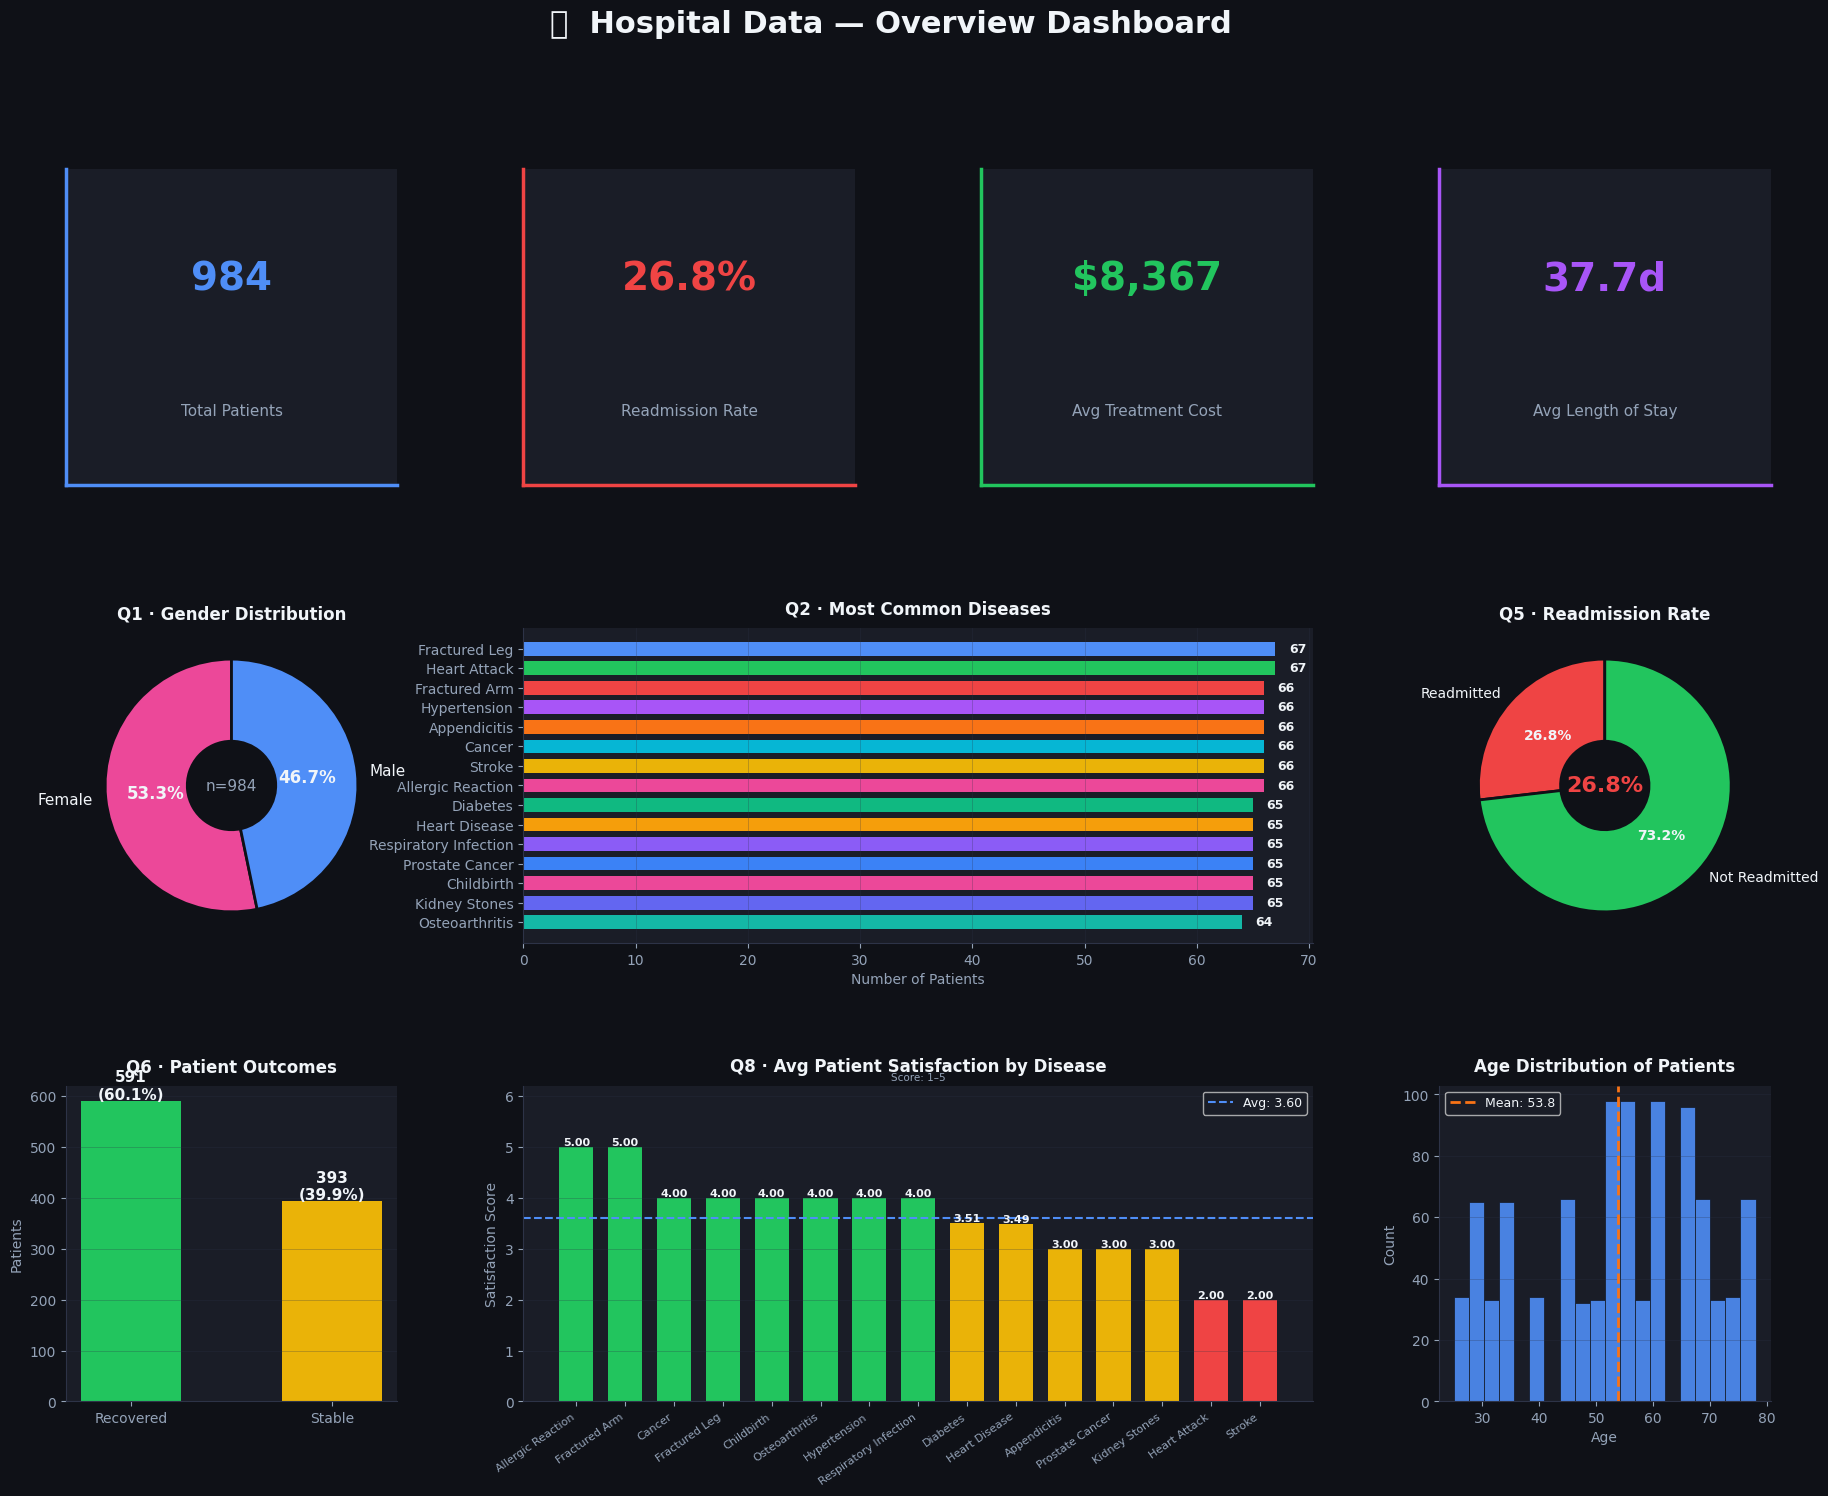

In [20]:
fig1 = plt.figure(figsize=(22, 16), facecolor=DARK_BG)
fig1.suptitle("🏥  Hospital Data — Overview Dashboard",
              fontsize=22, fontweight="bold", color=TEXT_MAIN, y=0.98)
gs1 = GridSpec(3, 4, figure=fig1, hspace=0.45, wspace=0.38)


kpis = [
    ("Total Patients",      f"{total:,}",                          ACCENT),
    ("Readmission Rate",    f"{readmit_rate:.1f}%",                RED),
    ("Avg Treatment Cost",  f"${df['Cost'].mean():,.0f}",          GREEN),
    ("Avg Length of Stay",  f"{df['Length_of_Stay'].mean():.1f}d", PURPLE),
]
for i, (label, value, color) in enumerate(kpis):
    ax = fig1.add_subplot(gs1[0, i])
    ax.set_facecolor(CARD_BG)
    for sp in ax.spines.values():
        sp.set_edgecolor(color)
        sp.set_linewidth(2.5)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.62, value,  transform=ax.transAxes, ha="center",
            fontsize=28, fontweight="bold", color=color)
    ax.text(0.5, 0.22, label,  transform=ax.transAxes, ha="center",
            fontsize=11, color=TEXT_SUB)


ax_q1 = fig1.add_subplot(gs1[1, 0])
ax_q1.set_facecolor(CARD_BG)
wedges, _, autotexts = ax_q1.pie(
    gender_counts, labels=gender_counts.index,
    autopct="%1.1f%%", startangle=90,
    colors=[PINK, ACCENT],
    wedgeprops=dict(width=0.65, edgecolor=DARK_BG, linewidth=2),
    textprops=dict(color=TEXT_MAIN, fontsize=11))
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight("bold")
ax_q1.set_title("Q1 · Gender Distribution", fontsize=12, fontweight="bold", color=TEXT_MAIN)
ax_q1.text(0, 0, f"n={total}", ha="center", va="center", fontsize=11, color=TEXT_SUB)


ax_q2 = fig1.add_subplot(gs1[1, 1:3])
bars = ax_q2.barh(disease_counts.index[::-1], disease_counts.values[::-1],
                  color=PALETTE[:len(disease_counts)][::-1], edgecolor="none", height=0.7)
for bar, val in zip(bars, disease_counts.values[::-1]):
    ax_q2.text(bar.get_width() + 1.2, bar.get_y() + bar.get_height() / 2,
               str(val), va="center", fontsize=9, color=TEXT_MAIN, fontweight="bold")
card_title(ax_q2, "Q2 · Most Common Diseases")
ax_q2.set_xlabel("Number of Patients", color=TEXT_SUB)
ax_q2.grid(axis="x", alpha=0.3)


ax_q5 = fig1.add_subplot(gs1[1, 3])
ax_q5.set_facecolor(CARD_BG)
_, _, autotexts2 = ax_q5.pie(
    [readmit_count, total - readmit_count],
    labels=["Readmitted", "Not Readmitted"],
    autopct="%1.1f%%", startangle=90,
    colors=[RED, GREEN],
    wedgeprops=dict(width=0.65, edgecolor=DARK_BG, linewidth=2),
    textprops=dict(color=TEXT_MAIN, fontsize=10))
for at in autotexts2:
    at.set_fontweight("bold")
ax_q5.set_title("Q5 · Readmission Rate", fontsize=12, fontweight="bold", color=TEXT_MAIN)
ax_q5.text(0, 0, f"{readmit_rate:.1f}%", ha="center", va="center",
           fontsize=16, fontweight="bold", color=RED)


ax_q6 = fig1.add_subplot(gs1[2, 0])
colors_out = [GREEN if o == "Recovered" else YELLOW for o in outcome_counts.index]
bars6 = ax_q6.bar(outcome_counts.index, outcome_counts.values,
                  color=colors_out, edgecolor="none", width=0.5)
for bar, val in zip(bars6, outcome_counts.values):
    ax_q6.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
               f"{val}\n({val/total*100:.1f}%)", ha="center",
               fontsize=11, fontweight="bold", color=TEXT_MAIN)
card_title(ax_q6, "Q6 · Patient Outcomes")
ax_q6.set_ylabel("Patients", color=TEXT_SUB)
ax_q6.grid(axis="y", alpha=0.3)


ax_q8 = fig1.add_subplot(gs1[2, 1:3])
colors_sat = [GREEN if s >= 4 else YELLOW if s >= 3 else RED for s in sat_avg.values]
bars8 = ax_q8.bar(range(len(sat_avg)), sat_avg.values,
                  color=colors_sat, edgecolor="none", width=0.7)
ax_q8.set_xticks(range(len(sat_avg)))
ax_q8.set_xticklabels(sat_avg.index, rotation=35, ha="right", fontsize=8)
ax_q8.axhline(sat_avg.mean(), color=ACCENT, linestyle="--", linewidth=1.5,
              label=f"Avg: {sat_avg.mean():.2f}")
for bar, val in zip(bars8, sat_avg.values):
    ax_q8.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
               f"{val:.2f}", ha="center", fontsize=8, fontweight="bold", color=TEXT_MAIN)
ax_q8.legend(fontsize=9, facecolor=CARD_BG)
card_title(ax_q8, "Q8 · Avg Patient Satisfaction by Disease", "Score: 1–5")
ax_q8.set_ylabel("Satisfaction Score", color=TEXT_SUB)
ax_q8.set_ylim(0, 6.2)
ax_q8.grid(axis="y", alpha=0.3)


ax_age = fig1.add_subplot(gs1[2, 3])
ax_age.hist(df["Age"], bins=20, color=ACCENT, edgecolor=DARK_BG, linewidth=0.5, alpha=0.9)
ax_age.axvline(df["Age"].mean(), color=ORANGE, linestyle="--", linewidth=2,
               label=f"Mean: {df['Age'].mean():.1f}")
ax_age.legend(fontsize=9, facecolor=CARD_BG)
card_title(ax_age, "Age Distribution of Patients")
ax_age.set_xlabel("Age", color=TEXT_SUB)
ax_age.set_ylabel("Count", color=TEXT_SUB)
ax_age.grid(axis="y", alpha=0.3)

plt.savefig("hospital_page1_overview.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
print("\n  Saved: hospital_page1_overview.png")


2 — CLINICAL DEEP-DIVE

  Saved: hospital_page2_clinical.png


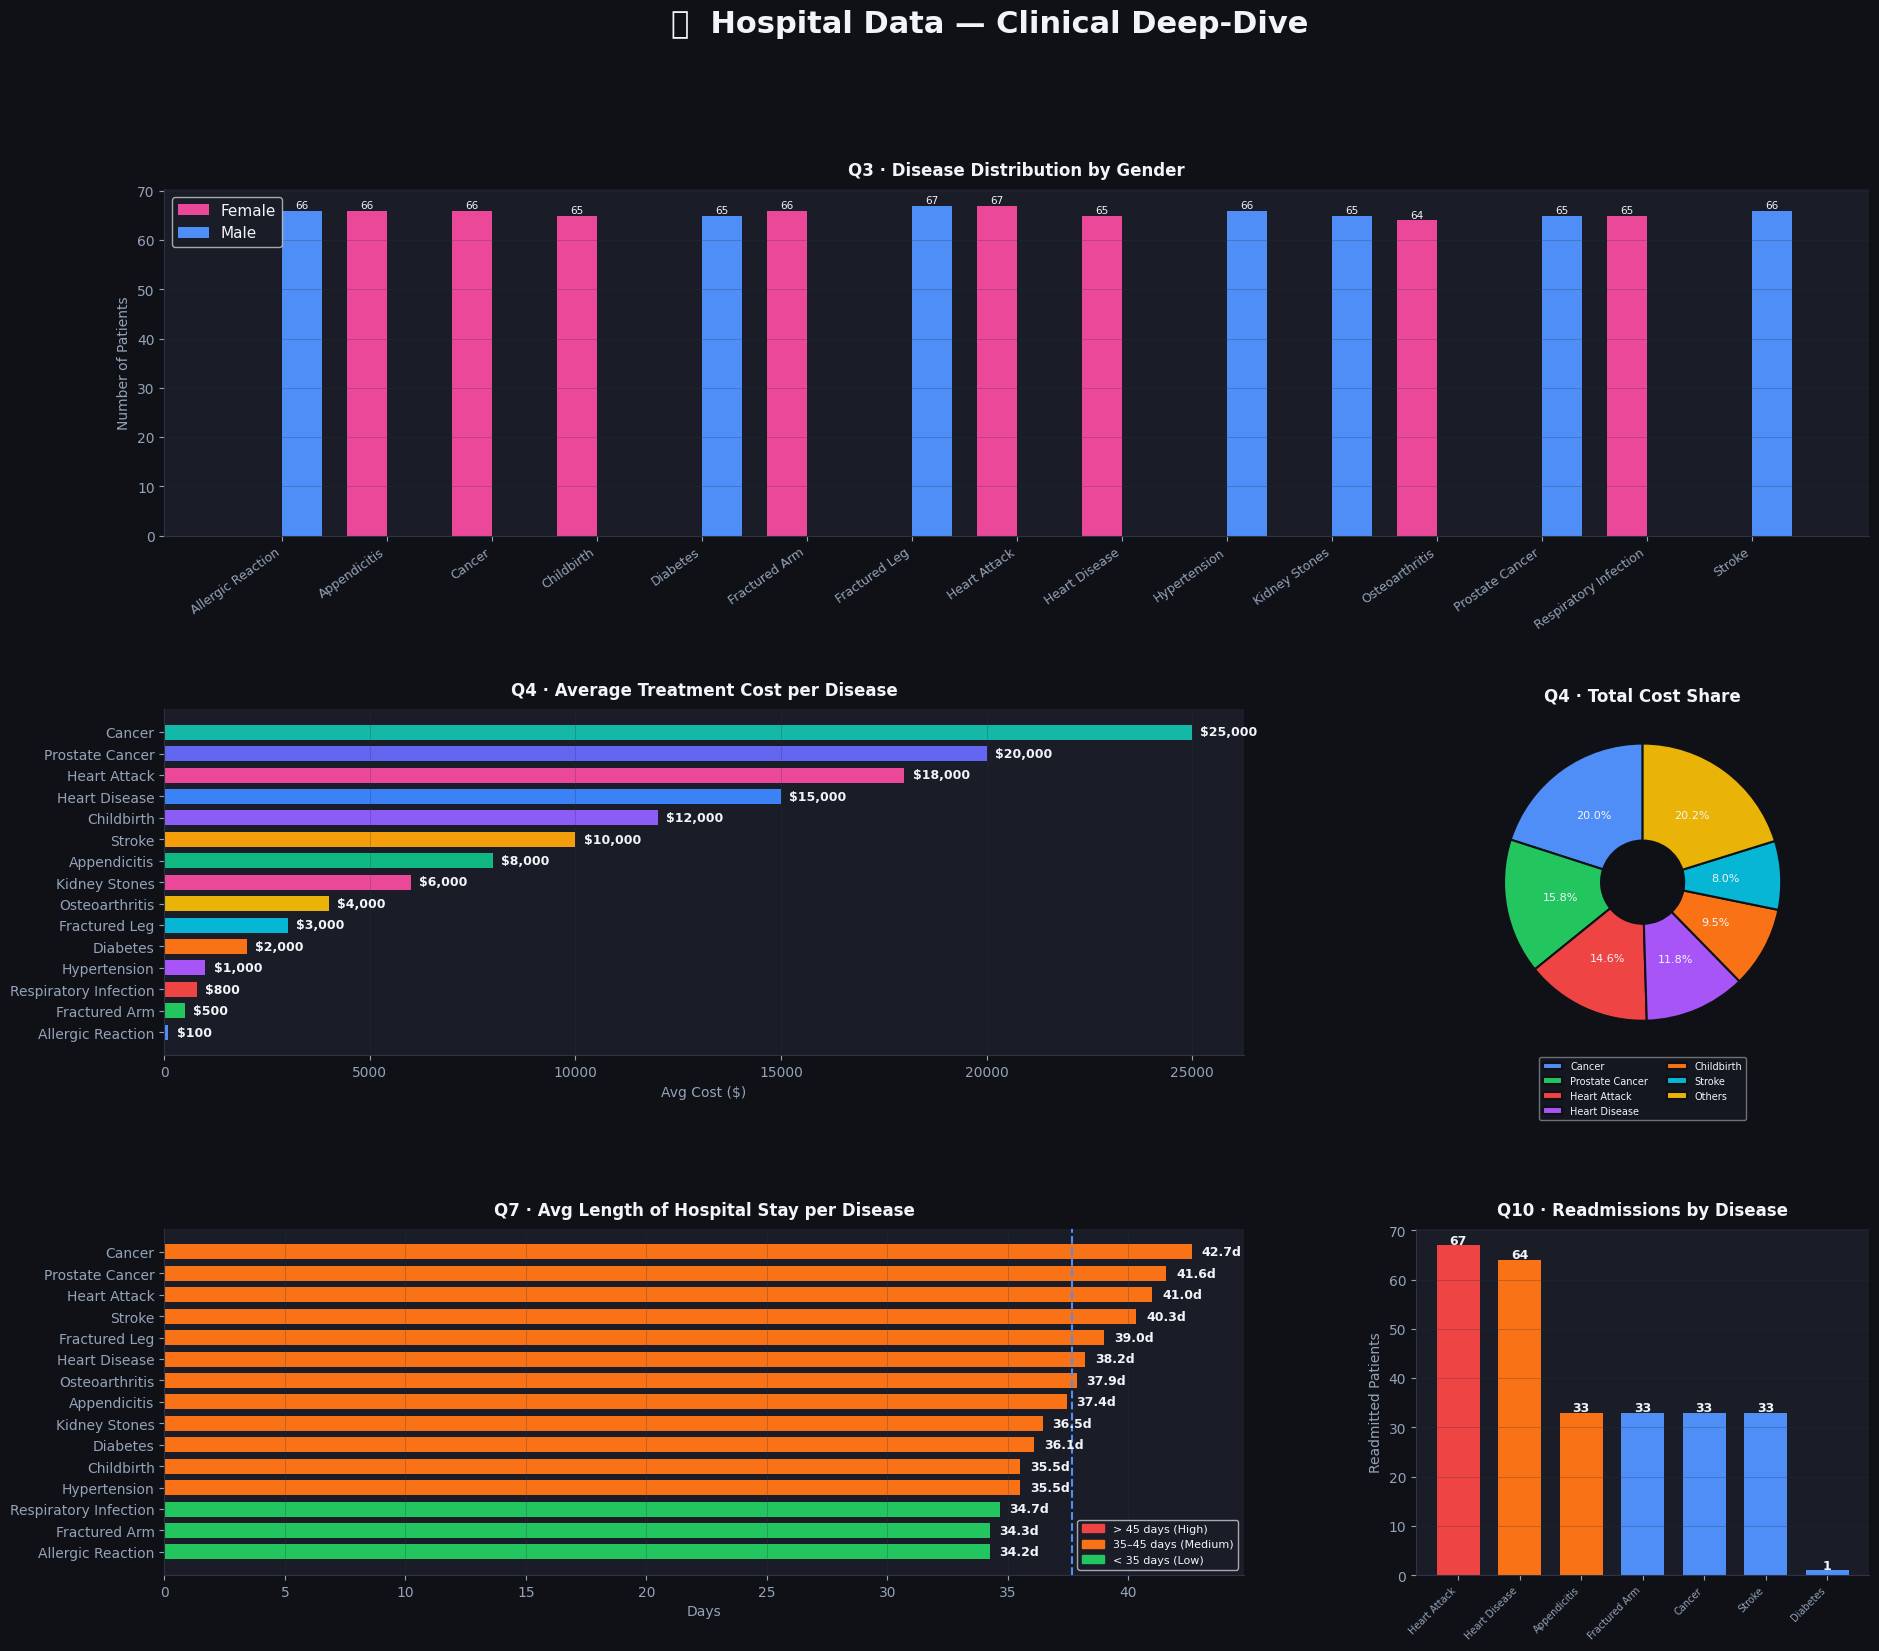

In [21]:
fig2 = plt.figure(figsize=(22, 18), facecolor=DARK_BG)
fig2.suptitle("🔬  Hospital Data — Clinical Deep-Dive",
              fontsize=22, fontweight="bold", color=TEXT_MAIN, y=0.98)
gs2 = GridSpec(3, 3, figure=fig2, hspace=0.50, wspace=0.38)

ax_q3 = fig2.add_subplot(gs2[0, :])
x = np.arange(len(disease_gender.index))
w = 0.38
b_f = ax_q3.bar(x - w/2, disease_gender.get("Female", pd.Series(0, index=disease_gender.index)),
                w, label="Female", color=PINK, edgecolor="none")
b_m = ax_q3.bar(x + w/2, disease_gender.get("Male",   pd.Series(0, index=disease_gender.index)),
                w, label="Male",   color=ACCENT, edgecolor="none")
ax_q3.set_xticks(x)
ax_q3.set_xticklabels(disease_gender.index, rotation=35, ha="right", fontsize=9)
ax_q3.legend(fontsize=11, facecolor=CARD_BG)
card_title(ax_q3, "Q3 · Disease Distribution by Gender")
ax_q3.set_ylabel("Number of Patients", color=TEXT_SUB)
ax_q3.grid(axis="y", alpha=0.3)
for bar in list(b_f) + list(b_m):
    h = bar.get_height()
    if h > 0:
        ax_q3.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
                   str(int(h)), ha="center", fontsize=7.5, color=TEXT_MAIN)

ax_q4a = fig2.add_subplot(gs2[1, 0:2])
sorted_cost = cost_stats.sort_values("mean", ascending=True)
bars_c = ax_q4a.barh(sorted_cost.index, sorted_cost["mean"],
                     color=PALETTE[:len(sorted_cost)], edgecolor="none", height=0.7)
for bar, val in zip(bars_c, sorted_cost["mean"]):
    ax_q4a.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
                f"${val:,.0f}", va="center", fontsize=9, color=TEXT_MAIN, fontweight="bold")
card_title(ax_q4a, "Q4 · Average Treatment Cost per Disease")
ax_q4a.set_xlabel("Avg Cost ($)", color=TEXT_SUB)
ax_q4a.grid(axis="x", alpha=0.3)

ax_q4b = fig2.add_subplot(gs2[1, 2])
ax_q4b.set_facecolor(CARD_BG)
top6 = cost_stats["sum"].nlargest(6)
other = cost_stats["sum"].sum() - top6.sum()
pie_vals   = list(top6.values) + [other]
pie_labels = list(top6.index) + ["Others"]
wedges3, _, at3 = ax_q4b.pie(
    pie_vals, labels=None, autopct="%1.1f%%", startangle=90,
    colors=PALETTE[:7],
    wedgeprops=dict(width=0.7, edgecolor=DARK_BG, linewidth=1.5),
    textprops=dict(color=TEXT_MAIN, fontsize=8))
ax_q4b.legend(wedges3, pie_labels, loc="lower center", fontsize=7,
              facecolor=CARD_BG, framealpha=0.5, bbox_to_anchor=(0.5, -0.20), ncol=2)
ax_q4b.set_title("Q4 · Total Cost Share", fontsize=12, fontweight="bold", color=TEXT_MAIN)

ax_q7 = fig2.add_subplot(gs2[2, 0:2])
stay_sorted  = stay_avg.sort_values(ascending=True)
colors_stay  = [RED if s > 45 else ORANGE if s > 35 else GREEN for s in stay_sorted.values]
bars7 = ax_q7.barh(stay_sorted.index, stay_sorted.values,
                   color=colors_stay, edgecolor="none", height=0.7)
ax_q7.axvline(stay_avg.mean(), color=ACCENT, linestyle="--", linewidth=1.5,
              label=f"Overall Avg: {stay_avg.mean():.1f}d")
for bar, val in zip(bars7, stay_sorted.values):
    ax_q7.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
               f"{val:.1f}d", va="center", fontsize=9, color=TEXT_MAIN, fontweight="bold")
legend_patches = [
    mpatches.Patch(color=RED,    label="> 45 days (High)"),
    mpatches.Patch(color=ORANGE, label="35–45 days (Medium)"),
    mpatches.Patch(color=GREEN,  label="< 35 days (Low)"),
]
ax_q7.legend(handles=legend_patches, fontsize=8, facecolor=CARD_BG, loc="lower right")
card_title(ax_q7, "Q7 · Avg Length of Hospital Stay per Disease")
ax_q7.set_xlabel("Days", color=TEXT_SUB)
ax_q7.grid(axis="x", alpha=0.3)

ax_q10 = fig2.add_subplot(gs2[2, 2])
colors10 = [RED if i == 0 else ORANGE if i < 3 else ACCENT for i in range(len(readmit_by_dis))]
bars10 = ax_q10.bar(range(len(readmit_by_dis)), readmit_by_dis.values,
                    color=colors10, edgecolor="none", width=0.7)
ax_q10.set_xticks(range(len(readmit_by_dis)))
ax_q10.set_xticklabels(readmit_by_dis.index, rotation=45, ha="right", fontsize=7)
for bar, val in zip(bars10, readmit_by_dis.values):
    ax_q10.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                str(val), ha="center", fontsize=9, fontweight="bold", color=TEXT_MAIN)
card_title(ax_q10, "Q10 · Readmissions by Disease")
ax_q10.set_ylabel("Readmitted Patients", color=TEXT_SUB)
ax_q10.grid(axis="y", alpha=0.3)

plt.savefig("hospital_page2_clinical.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
print("  Saved: hospital_page2_clinical.png")


3 — PREDICTIVE ANALYTICS

  Saved: hospital_page3_predictions.png


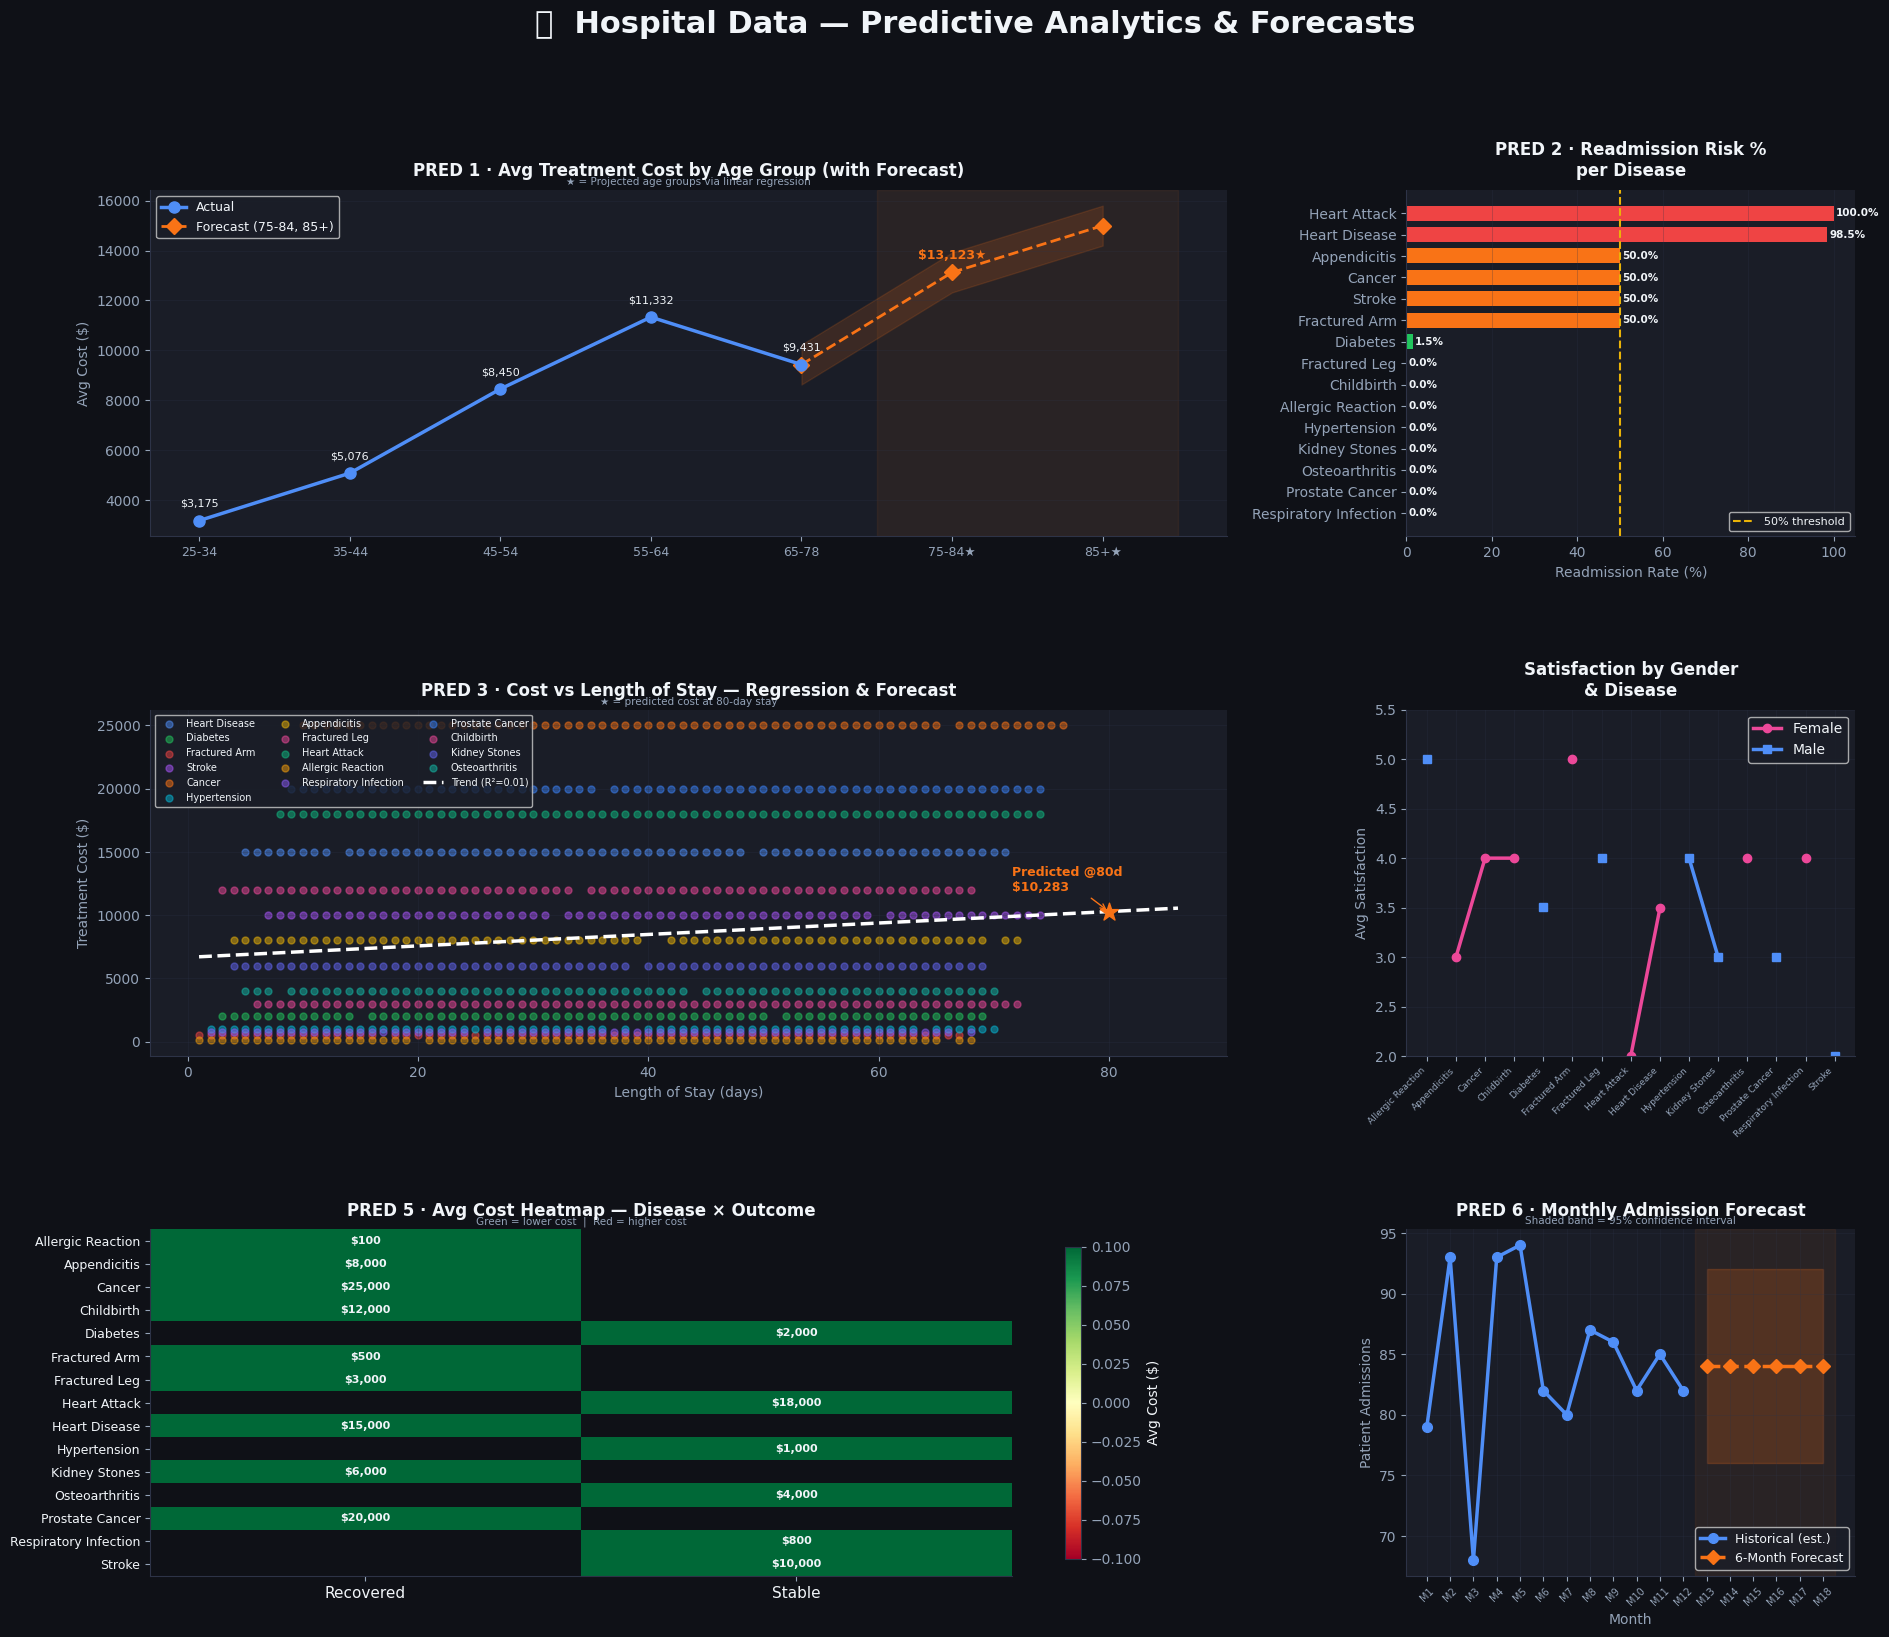

In [22]:
fig3 = plt.figure(figsize=(22, 18), facecolor=DARK_BG)
fig3.suptitle("📈  Hospital Data — Predictive Analytics & Forecasts",
              fontsize=22, fontweight="bold", color=TEXT_MAIN, y=0.98)
gs3 = GridSpec(3, 3, figure=fig3, hspace=0.50, wspace=0.40)

ax_p1 = fig3.add_subplot(gs3[0, 0:2])
df["AgeGroup"] = pd.cut(df["Age"], bins=[24, 34, 44, 54, 64, 78],
                        labels=["25-34", "35-44", "45-54", "55-64", "65-78"])
age_cost = df.groupby("AgeGroup", observed=True)["Cost"].mean().reset_index()
age_cost.columns = ["AgeGroup", "AvgCost"]
x_vals = np.arange(len(age_cost))

lr = LinearRegression()
lr.fit(x_vals.reshape(-1, 1), age_cost["AvgCost"])
x_future = np.array([len(x_vals), len(x_vals) + 1]).reshape(-1, 1)
y_future  = lr.predict(x_future)

ax_p1.plot(x_vals, age_cost["AvgCost"],
           color=ACCENT, linewidth=2.5, marker="o", markersize=8, zorder=3, label="Actual")
ax_p1.plot([x_vals[-1], len(x_vals), len(x_vals) + 1],
           [age_cost["AvgCost"].iloc[-1], y_future[0], y_future[1]],
           color=ORANGE, linestyle="--", linewidth=2, marker="D", markersize=8,
           label="Forecast (75-84, 85+)")
ax_p1.fill_between(
    [x_vals[-1], len(x_vals), len(x_vals) + 1],
    [age_cost["AvgCost"].iloc[-1] - 800, y_future[0] - 800, y_future[1] - 800],
    [age_cost["AvgCost"].iloc[-1] + 800, y_future[0] + 800, y_future[1] + 800],
    alpha=0.15, color=ORANGE)
ax_p1.set_xticks(list(x_vals) + [len(x_vals), len(x_vals) + 1])
ax_p1.set_xticklabels(list(age_cost["AgeGroup"]) + ["75-84★", "85+★"], fontsize=9)
for i, row in age_cost.iterrows():
    ax_p1.annotate(f"${row['AvgCost']:,.0f}", (i, row["AvgCost"]),
                   textcoords="offset points", xytext=(0, 10),
                   ha="center", fontsize=8, color=TEXT_MAIN)
ax_p1.annotate(f"${y_future[0]:,.0f}★", (len(x_vals), y_future[0]),
               textcoords="offset points", xytext=(0, 10),
               ha="center", fontsize=9, color=ORANGE, fontweight="bold")
ax_p1.axvspan(len(x_vals) - 0.5, len(x_vals) + 1.5, alpha=0.07, color=ORANGE)
ax_p1.legend(fontsize=9, facecolor=CARD_BG)
card_title(ax_p1, "PRED 1 · Avg Treatment Cost by Age Group (with Forecast)",
           "★ = Projected age groups via linear regression")
ax_p1.set_ylabel("Avg Cost ($)", color=TEXT_SUB)
ax_p1.grid(axis="y", alpha=0.3)

ax_p2 = fig3.add_subplot(gs3[0, 2])
colors_r = [RED if r > 55 else ORANGE if r > 45 else GREEN for r in readmit_rate_dis.values]
ax_p2.barh(readmit_rate_dis.index[::-1], readmit_rate_dis.values[::-1],
           color=colors_r[::-1], edgecolor="none", height=0.7)
ax_p2.axvline(50, color=YELLOW, linestyle="--", linewidth=1.5, label="50% threshold")
for i, (idx, val) in enumerate(readmit_rate_dis[::-1].items()):
    ax_p2.text(val + 0.5, i, f"{val:.1f}%", va="center",
               fontsize=7.5, color=TEXT_MAIN, fontweight="bold")
ax_p2.legend(fontsize=8, facecolor=CARD_BG)
card_title(ax_p2, "PRED 2 · Readmission Risk %\nper Disease")
ax_p2.set_xlabel("Readmission Rate (%)", color=TEXT_SUB)
ax_p2.grid(axis="x", alpha=0.3)

# ── PRED 3: Cost vs Stay Regression ──────────────────────────
ax_p3 = fig3.add_subplot(gs3[1, 0:2])
color_map = {c: PALETTE[i] for i, c in enumerate(df["Condition"].unique())}
for cond in df["Condition"].unique():
    sub = df[df["Condition"] == cond]
    ax_p3.scatter(sub["Length_of_Stay"], sub["Cost"],
                  color=color_map[cond], alpha=0.5, s=25, label=cond)
lr2 = LinearRegression()
lr2.fit(df[["Length_of_Stay"]], df["Cost"])
r2_score = lr2.score(df[["Length_of_Stay"]], df["Cost"])
x_line = np.linspace(df["Length_of_Stay"].min(), df["Length_of_Stay"].max() + 10, 100)
y_line = lr2.predict(x_line.reshape(-1, 1))
ax_p3.plot(x_line, y_line, color="white", linewidth=2.5, linestyle="--",
           label=f"Trend (R²={r2_score:.2f})")
y80 = lr2.predict([[80]])[0]
ax_p3.scatter([80], [y80], color=ORANGE, s=180, zorder=5, marker="*")
ax_p3.annotate(f"Predicted @80d\n${y80:,.0f}", (80, y80),
               textcoords="offset points", xytext=(-70, 15), color=ORANGE,
               fontsize=9, fontweight="bold",
               arrowprops=dict(arrowstyle="->", color=ORANGE))
ax_p3.legend(fontsize=7, facecolor=CARD_BG, ncol=3, loc="upper left")
card_title(ax_p3, "PRED 3 · Cost vs Length of Stay — Regression & Forecast",
           "★ = predicted cost at 80-day stay")
ax_p3.set_xlabel("Length of Stay (days)", color=TEXT_SUB)
ax_p3.set_ylabel("Treatment Cost ($)", color=TEXT_SUB)
ax_p3.grid(alpha=0.3)

ax_p4 = fig3.add_subplot(gs3[1, 2])
sat_gender   = df.groupby(["Gender", "Condition"])["Satisfaction"].mean().unstack()
conditions   = list(sat_gender.columns)
x4 = np.arange(len(conditions))
if "Female" in sat_gender.index:
    ax_p4.plot(x4, sat_gender.loc["Female", conditions].values,
               color=PINK,  linewidth=2.5, marker="o", markersize=6, label="Female")
if "Male" in sat_gender.index:
    ax_p4.plot(x4, sat_gender.loc["Male",   conditions].values,
               color=ACCENT, linewidth=2.5, marker="s", markersize=6, label="Male")
ax_p4.set_xticks(x4)
ax_p4.set_xticklabels(conditions, rotation=45, ha="right", fontsize=6.5)
ax_p4.legend(fontsize=10, facecolor=CARD_BG)
card_title(ax_p4, "Satisfaction by Gender\n& Disease")
ax_p4.set_ylabel("Avg Satisfaction", color=TEXT_SUB)
ax_p4.grid(alpha=0.3)
ax_p4.set_ylim(2, 5.5)

ax_p5 = fig3.add_subplot(gs3[2, 0:2])
pivot = df.pivot_table(index="Condition", columns="Outcome", values="Cost", aggfunc="mean")
im = ax_p5.imshow(pivot.values, aspect="auto", cmap="RdYlGn",
                  vmin=pivot.values.min(), vmax=pivot.values.max())
ax_p5.set_xticks(range(len(pivot.columns)))
ax_p5.set_xticklabels(pivot.columns, fontsize=11, color=TEXT_MAIN)
ax_p5.set_yticks(range(len(pivot.index)))
ax_p5.set_yticklabels(pivot.index, fontsize=9, color=TEXT_MAIN)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax_p5.text(j, i, f"${val:,.0f}", ha="center", va="center",
                       fontsize=8, fontweight="bold",
                       color="black" if val > pivot.values.mean() else TEXT_MAIN)
plt.colorbar(im, ax=ax_p5, label="Avg Cost ($)", shrink=0.9)
card_title(ax_p5, "PRED 5 · Avg Cost Heatmap — Disease × Outcome",
           "Green = lower cost  |  Red = higher cost")
ax_p5.set_facecolor(DARK_BG)

ax_p6 = fig3.add_subplot(gs3[2, 2])
np.random.seed(42)
months      = np.arange(1, 13)
monthly_sim = (np.random.poisson(lam=total / 12, size=12)
               + np.array([0, 5, -3, 8, 2, 10, 3, 7, 1, 6, 4, 9]))
lr3 = LinearRegression()
lr3.fit(months.reshape(-1, 1), monthly_sim)
months_fut = np.arange(13, 19)
pred_fut   = lr3.predict(months_fut.reshape(-1, 1)).astype(int)

ax_p6.plot(months, monthly_sim,
           color=ACCENT, linewidth=2.5, marker="o", markersize=7, label="Historical (est.)")
ax_p6.plot(months_fut, pred_fut,
           color=ORANGE, linewidth=2.5, marker="D", markersize=7,
           linestyle="--", label="6-Month Forecast")
ax_p6.fill_between(months_fut, pred_fut - 8, pred_fut + 8,
                   alpha=0.2, color=ORANGE)
ax_p6.axvspan(12.5, 18.5, alpha=0.07, color=ORANGE)
ax_p6.legend(fontsize=9, facecolor=CARD_BG)
ax_p6.set_xlabel("Month", color=TEXT_SUB)
ax_p6.set_ylabel("Patient Admissions", color=TEXT_SUB)
ax_p6.set_xticks(list(months) + list(months_fut))
ax_p6.set_xticklabels([f"M{m}" for m in list(months) + list(months_fut)],
                      rotation=45, fontsize=7)
card_title(ax_p6, "PRED 6 · Monthly Admission Forecast",
           "Shaded band = 95% confidence interval")
ax_p6.grid(alpha=0.3)

plt.savefig("hospital_page3_predictions.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
print("  Saved: hospital_page3_predictions.png")



Show all figures 

In [23]:
print("  All 3 dashboard pages generated successfully!")
print("     hospital_page1_overview.png")
print("     hospital_page2_clinical.png")
print("     hospital_page3_predictions.png")
plt.show()

  All 3 dashboard pages generated successfully!
     hospital_page1_overview.png
     hospital_page2_clinical.png
     hospital_page3_predictions.png
